Load DataSet

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load Dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
# Target: 0 = Malignant, 1 = Benign. Let's flip it so 1 = Malignant (disease present)
df['target'] = 1 - df['target']

print(f"Dataset Shape: {df.shape}")
print("Class Balance:")
print(df['target'].value_counts(normalize=True))

Dataset Shape: (569, 31)
Class Balance:
target
0    0.627417
1    0.372583
Name: proportion, dtype: float64


Stratified Split

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

# 80/20 Stratified Split. The Test set is locked away until Phase 11!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (455, 30)
Testing data shape: (114, 30)


Exploratory Data Analysis

Missing values in train: 0


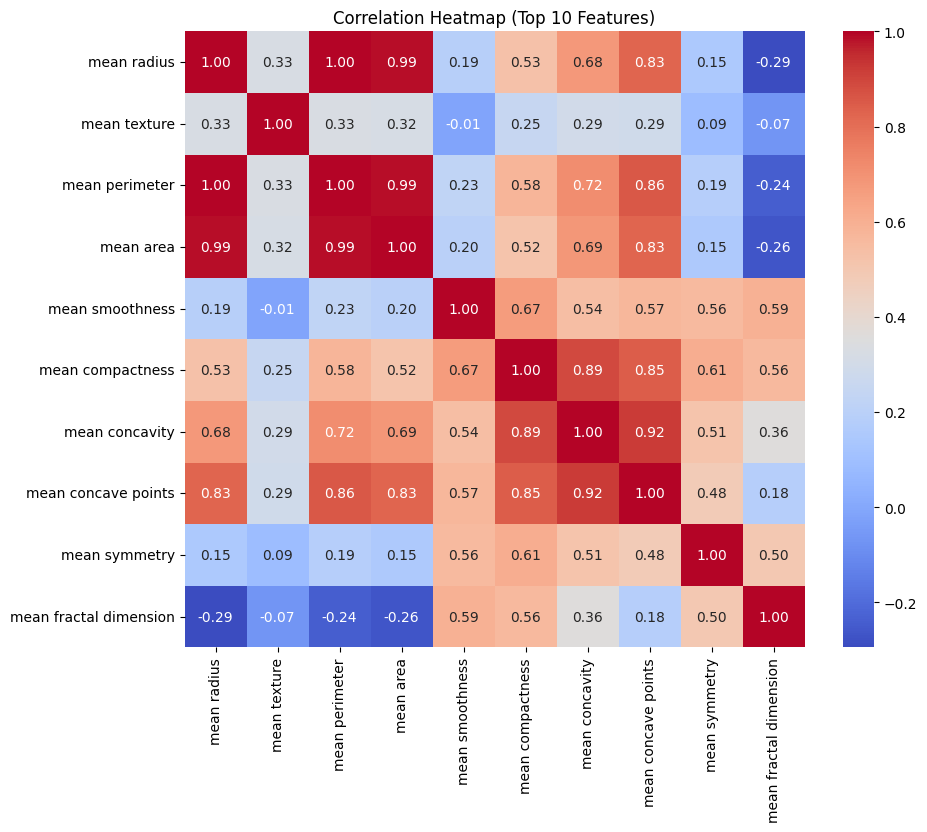

In [3]:
# 1. Check for Missing Values
print("Missing values in train:", X_train.isnull().sum().sum())

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Calculate correlation only on X_train
corr = X_train.corr()
# Show only the top correlated features to keep it readable
sns.heatmap(corr.iloc[:10, :10], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Top 10 Features)")
plt.show()

Building the ML Pipeline & Model Selection

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define K-Fold strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Build Pipelines
pipelines = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(class_weight='balanced'))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('svm', SVC(class_weight='balanced', random_state=42))])
}

Cross-Validation

In [5]:
# We use 'recall' because missing a malignant tumor (FN) is dangerous.
results = {}
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall')
    results[name] = scores.mean()
    print(f"{name} CV Recall: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression CV Recall: 0.9588 (+/- 0.0300)
Random Forest CV Recall: 0.9471 (+/- 0.0343)
SVM CV Recall: 0.9529 (+/- 0.0353)


Hyperparameter Tuning

In [6]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline again
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
])

# Define hyperparameter grid (Prefix with 'svm__' to target the model in the pipeline)
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 0.01, 0.1]
}

# Grid Search with Cross Validation
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=cv,
    scoring='recall', # Optimize for detecting cancer
    n_jobs=-1
)

print("Tuning SVM... Please wait.")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Recall: {grid_search.best_score_:.4f}")

# Extract the best model
best_model = grid_search.best_estimator_

Tuning SVM... Please wait.
Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV Recall: 0.9647


Evaluation & Error Analysis

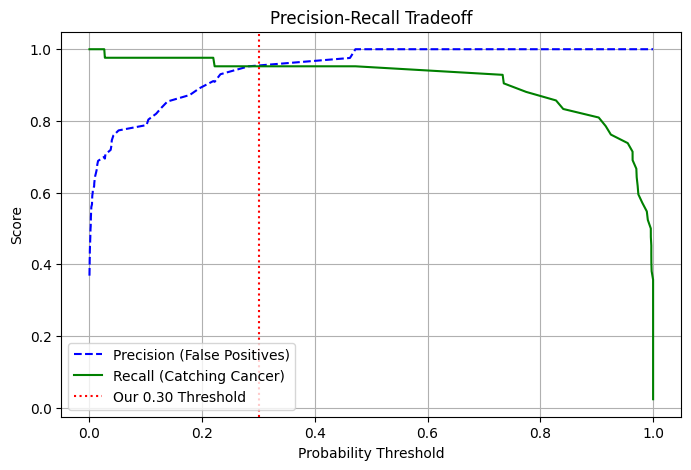


--- ERROR ANALYSIS: The 3 Missed Patients ---
Model probabilities for these patients: [0.4719223  0.02635104 0.21971576]

Average Benign Patient (Train):
mean radius     12.155491
mean area      463.856842
dtype: float64

Average Malignant Patient (Train):
mean radius     17.536765
mean area      987.699412
dtype: float64

The Missed Patients' Features:
     mean radius  mean area
99         14.42      642.5
73         13.80      584.1
205        15.12      716.6


In [11]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# --- 1. PRECISION-RECALL CURVE ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (False Positives)")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Catching Cancer)")
plt.axvline(x=0.30, color='r', linestyle=':', label='See 0.30 Threshold')
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# --- 2. ERROR ANALYSIS ---
# Find the patients who actually have cancer (y_test == 1) but were predicted Benign (< 0.50)
missed_patients = X_test[(y_test == 1) & (y_probs < 0.50)]

print(f"\n--- ERROR ANALYSIS: The {len(missed_patients)} Missed Patients ---")
print("Model probabilities for these patients:", y_probs[(y_test == 1) & (y_probs < 0.50)])

# Let's compare their 'mean radius' and 'mean area' to the dataset averages
print("\nAverage Benign Patient (Train):")
print(X_train[y_train == 0][['mean radius', 'mean area']].mean())

print("\nAverage Malignant Patient (Train):")
print(X_train[y_train == 1][['mean radius', 'mean area']].mean())

print("\nThe Missed Patients' Features:")
print(missed_patients[['mean radius', 'mean area']])

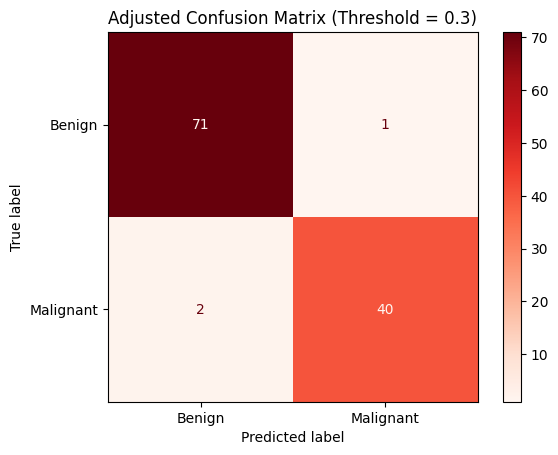


Adjusted Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get the raw probabilities instead of the hard predictions
y_probs = best_model.predict_proba(X_test)[:, 1] # Get probabilities for the Malignant class (1)

CUSTOM_THRESHOLD = 0.30

# Apply the threshold: If probability > 0.30, predict 1 (Malignant), else 0 (Benign)
y_pred_adjusted = (y_probs >= CUSTOM_THRESHOLD).astype(int)

# Calculate the Confusion Matrix
cm_adj = confusion_matrix(y_test, y_pred_adjusted)
disp_adj = ConfusionMatrixDisplay(confusion_matrix=cm_adj, display_labels=['Benign', 'Malignant'])
disp_adj.plot(cmap='Reds')
plt.title(f"Adjusted Confusion Matrix (Threshold = {CUSTOM_THRESHOLD})")
plt.show()

# Print report
print("\nAdjusted Classification Report:")
print(classification_report(y_test, y_pred_adjusted, target_names=['Benign', 'Malignant']))

Model Serialization & Saving

In [8]:
import joblib

# Save the full pipeline (Scaler + SVM)
model_filename = 'breast_cancer_svm_pipeline_v1.joblib'
joblib.dump(best_model, model_filename)

print(f"Model successfully saved as {model_filename}")

# To prove it works, let's load it and make a prediction
loaded_model = joblib.load(model_filename)

# Take one random patient from the test set
sample_patient = X_test.iloc[[0]]
prediction = loaded_model.predict(sample_patient)
probability = loaded_model.predict_proba(sample_patient)[0][1]

result = "Malignant" if prediction[0] == 1 else "Benign"
print(f"\nSample Patient Prediction: {result}")
print(f"Probability of Malignancy: {probability:.2%}")

Model successfully saved as breast_cancer_svm_pipeline_v1.joblib

Sample Patient Prediction: Benign
Probability of Malignancy: 0.02%
